In [ ]:
from datasets.cross_tissue_atlas import CrossTissueDataset
import os

import hydra
from omegaconf import OmegaConf

import torch
import numpy as np
from geomloss import SamplesLoss

# silence all warnings
import warnings
warnings.filterwarnings("ignore")

/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
train_set = CrossTissueDataset(
    root="data",
    split="train",
)

test_set = CrossTissueDataset(
    root="data",
    split="test",
)

In [3]:
adata = test_set.adata

In [4]:
train_donors = train_set.donors
test_donors = test_set.donors
print(train_donors)
print(test_donors)

['GTEX-12BJ1', 'GTEX-13N11', 'GTEX-144GM', 'GTEX-145ME', 'GTEX-15CHR', 'GTEX-15EOM', 'GTEX-15RIE', 'GTEX-15SB6']
['GTEX-16BQI', 'GTEX-1CAMR', 'GTEX-1CAMS', 'GTEX-1HSMQ', 'GTEX-1I1GU', 'GTEX-1ICG6', 'GTEX-1MCC2', 'GTEX-1R9PN']


In [5]:
donor_centroids = {}
for donor in test_donors:
    donor_data = test_set.adata[test_set.adata.obs['donor_id'] == donor]
    centroid = np.nan_to_num(donor_data.obsm['X_pca']).mean(axis=0).flatten()
    donor_centroids[donor] = centroid
for donor in train_donors:
    donor_data = train_set.adata[train_set.adata.obs['donor_id'] == donor]
    centroid = np.nan_to_num(donor_data.obsm['X_pca']).mean(axis=0).flatten()
    donor_centroids[donor] = centroid

# for each test donor, get the nearest train donor
test_to_train_donor = {}
for test_donor in test_donors:
    test_centroid = donor_centroids[test_donor]
    nearest_train_donor = None
    nearest_distance = float('inf')
    for train_donor in train_donors:
        train_centroid = donor_centroids[train_donor]
        distance = torch.norm(torch.tensor(test_centroid) - torch.tensor(train_centroid)).item()
        if distance < nearest_distance:
            nearest_distance = distance
            nearest_train_donor = train_donor
    test_to_train_donor[test_donor] = nearest_train_donor

print("Test to Train Donor Mapping:")
for test_donor, train_donor in test_to_train_donor.items():
    print(f"{test_donor} -> {train_donor}")

Test to Train Donor Mapping:
GTEX-16BQI -> GTEX-15SB6
GTEX-1CAMR -> GTEX-15EOM
GTEX-1CAMS -> GTEX-15EOM
GTEX-1HSMQ -> GTEX-145ME
GTEX-1I1GU -> GTEX-12BJ1
GTEX-1ICG6 -> GTEX-15RIE
GTEX-1MCC2 -> GTEX-15EOM
GTEX-1R9PN -> GTEX-15SB6


In [6]:
output_dir = '/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/'

configs = os.listdir(output_dir)

config_name = [x for x in configs if x.startswith('crosstissue_gnn_energy_')][0]
print(config_name)
config_path = os.path.join(output_dir, config_name, 'config.yaml')
if not os.path.exists(config_path):
    raise FileNotFoundError(f"Config not found at {config_path}")

config = OmegaConf.load(config_path)

best_model_path = os.path.join(output_dir, config_name, 'best_model.pt')
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Best model not found at {best_model_path}")

dct_encoder = hydra.utils.instantiate(config.encoder)
dct_generator = hydra.utils.instantiate(config.generator)

device = 'cuda'
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)

dct_encoder.load_state_dict(checkpoint['encoder_state_dict'])
dct_generator.load_state_dict(checkpoint['generator_state_dict'])

epoch = checkpoint.get('epoch', 'unknown')
loss = checkpoint.get('loss', float('nan'))

dct_encoder.to(device)
dct_generator.to(device)
dct_encoder.eval()
dct_generator.eval();

crosstissue_gnn_energy_8522a731d44ff2b5f1e00fb4f78bd6b2


In [7]:
energy = SamplesLoss("energy")

energy_dists = []

for p in range(8):

    for _ in range(100):

        batch = test_set[p]

        source_samples = batch['source_samples'].to(device).unsqueeze(0)
        target_samples = batch['target_samples'].to(device).unsqueeze(0)

        with torch.no_grad():
            source_latent = dct_encoder(source_samples)
            target_latent = dct_encoder(target_samples)

            # print(source_latent.shape)

            samples = dct_generator.sample(source_samples.reshape(-1, 10), source_latent, target_latent)

        e_dist = energy(samples.squeeze(0), target_samples.squeeze(0)).item()
        energy_dists.append(e_dist)

print("mean Energy Distance:", np.mean(energy_dists))
print('s.e.m', np.std(energy_dists) / np.sqrt(len(energy_dists)))

mean Energy Distance: 0.09386383384466171
s.e.m 0.001118550478843465


In [8]:
output_dir = '/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/'

configs = os.listdir(output_dir)

config_name = [x for x in configs if x.startswith('crosstissue_onehot_energy_')][0]
print(config_name)
config_path = os.path.join(output_dir, config_name, 'config.yaml')
if not os.path.exists(config_path):
    raise FileNotFoundError(f"Config not found at {config_path}")

config = OmegaConf.load(config_path)

# Detect model types
encoder_type, generator_type = ('esm', 'progen2')

best_model_path = os.path.join(output_dir, config_name, 'best_model.pt')
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Best model not found at {best_model_path}")

onehot_encoder = hydra.utils.instantiate(config.encoder)
onehot_generator = hydra.utils.instantiate(config.generator)

device = 'cuda'
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)

onehot_encoder.load_state_dict(checkpoint['encoder_state_dict'])
onehot_generator.load_state_dict(checkpoint['generator_state_dict'])

epoch = checkpoint.get('epoch', 'unknown')
loss = checkpoint.get('loss', float('nan'))

print(epoch, loss)

onehot_encoder.to(device)
onehot_generator.to(device)
onehot_encoder.eval()
onehot_generator.eval();

crosstissue_onehot_energy_2d3f905937672c28ee5d7aa09d33b5a3
2800 1.3413276672363281


In [9]:
energy = SamplesLoss("energy")

energy_dists = []

for p in range(8):

    for _ in range(100):

        batch = test_set[p]

        source_samples = batch['source_samples'].to(device).unsqueeze(0)
        target_samples = batch['target_samples'].to(device).unsqueeze(0)

        source_donor = batch['source_metadata']['donor_id']
        target_donor = batch['target_metadata']['donor_id']

        nearest_source_donor = test_to_train_donor[source_donor]
        nearest_target_donor = test_to_train_donor[target_donor]

        nn_source_idx = torch.tensor(train_set.donors.index(nearest_source_donor)).cuda()
        nn_target_idx = torch.tensor(train_set.donors.index(nearest_target_donor)).cuda()

        with torch.no_grad():
            source_latent = onehot_encoder(nn_source_idx).repeat(source_samples.shape[0], 1)
            target_latent = onehot_encoder(nn_target_idx).repeat(target_samples.shape[0], 1)

            # print(source_latent.shape)

            samples = onehot_generator.sample(source_samples.reshape(-1, 10), source_latent, target_latent)

        e_dist = energy(samples.squeeze(0), 
                        target_samples.squeeze(0)).item()
        energy_dists.append(e_dist)

print("mean Energy Distance:", np.mean(energy_dists))
print('s.e.m', np.std(energy_dists) / np.sqrt(len(energy_dists)))

mean Energy Distance: 0.3021542727947235
s.e.m 0.004038663269214168


In [19]:
import scvi
import scanpy as sc
from sklearn.neighbors import NearestNeighbors

In [18]:
adata_scvi = adata.copy()

sc.pp.highly_variable_genes(
    adata_scvi,
    n_top_genes=500,
    flavor="seurat",
    batch_key="donor_id",
    subset=True,
)

scvi.model.SCVI.setup_anndata(
    adata_scvi,
    batch_key="donor_id",
)

model = scvi.model.SCVI.load('/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/batch_scvi_model', adata_scvi)

INFO     File /orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/batch_scvi_model/model.pt already 
         downloaded                                                                                                


/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/gokulg/.local/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /orcd/home/002/gokulg/miniforge3/envs/gde/lib/python ...
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [20]:
# fit nearest neighbors on adata
nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(adata_scvi.X)

energy = SamplesLoss("energy")

/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/sklearn/neighbors/_base.py:598: UserWarning: cannot use tree with sparse input: using brute force
  warnings.warn("cannot use tree with sparse input: using brute force")


In [23]:
# Precompute all transformations for each donor pair
from collections import defaultdict

energy_dists = []

for p in range(8):
    # Collect all source indices and target info for this partition
    batches_info = []
    for _ in range(10):
        batch = test_set[p]
        batches_info.append(batch)
    
    # Group by target donor to batch the scVI calls
    donor_groups = defaultdict(list)
    for i, batch in enumerate(batches_info):
        target_donor = batch['target_metadata']['donor_id']
        donor_groups[target_donor].append((i, batch))
    
    # Process each donor group together
    results = [None] * 10
    for target_donor, group in donor_groups.items():
        # Combine all source indices for this target donor
        all_source_inds = np.concatenate([b['source_metadata']['adata_indices'] for _, b in group])
        adata_source = adata_scvi[all_source_inds].copy()
        
        # Single scVI call for all samples going to this donor
        transformed = model.get_normalized_expression(
            adata_source, batch_size=512, transform_batch=target_donor
        )
        
        # Split results back
        offset = 0
        for i, batch in group:
            n_samples = len(batch['source_metadata']['adata_indices'])
            results[i] = (transformed[offset:offset+n_samples], batch['target_samples'])
            offset += n_samples
    
    # Compute energy distances
    for transformed, target_samples in results:
        nns = nbrs.kneighbors(transformed, return_distance=False)
        snapped = adata_scvi.obsm['X_pca'][nns.flatten(), :10]
        e_dist = energy(torch.tensor(snapped), target_samples.squeeze(0)).item()
        energy_dists.append(e_dist)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


...

/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but NearestNeighbors was fitted without feature names
  warnings.warn(
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but NearestNeighbors was fitted without feature names
  warnings.warn(
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but NearestNeighbors was fitted without feature names
  warnings.warn(
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature nam

In [24]:
print("mean Energy Distance:", np.mean(energy_dists))
print('s.e.m', np.std(energy_dists) / np.sqrt(len(energy_dists)))

mean Energy Distance: 1.21500164270401
s.e.m 0.04703384802655165


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

Source donor: GTEX-16BQI
Target donors: ['GTEX-1CAMR', 'GTEX-1CAMS', 'GTEX-1HSMQ', 'GTEX-1I1GU', 'GTEX-1ICG6', 'GTEX-1MCC2', 'GTEX-1R9PN']
Source has 11508 cells


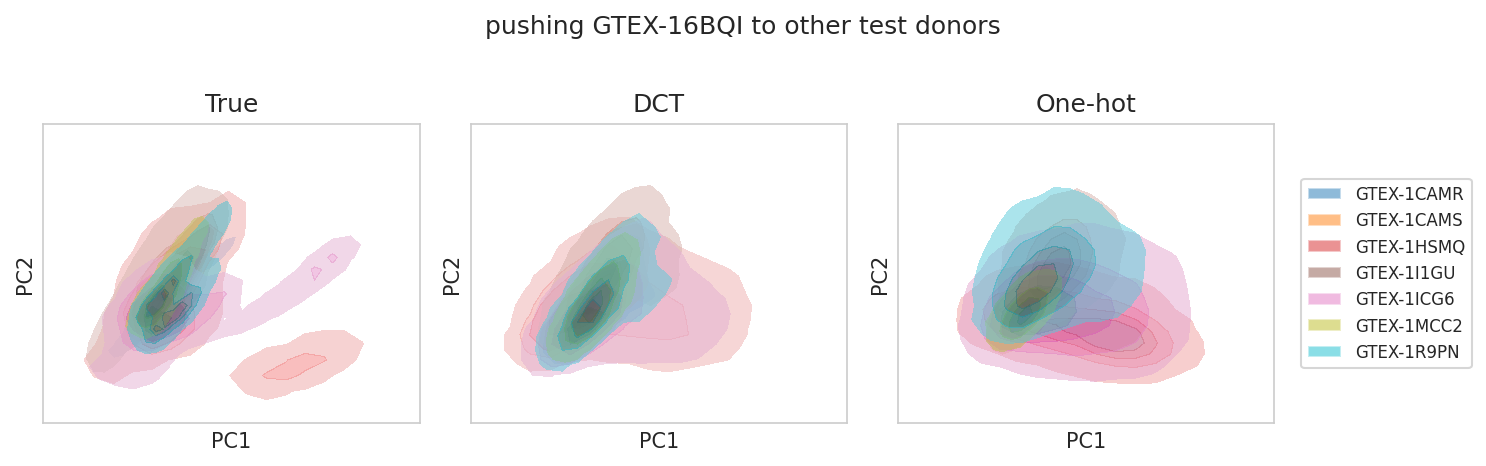

Source donor: GTEX-1CAMR
Target donors: ['GTEX-16BQI', 'GTEX-1CAMS', 'GTEX-1HSMQ', 'GTEX-1I1GU', 'GTEX-1ICG6', 'GTEX-1MCC2', 'GTEX-1R9PN']
Source has 40 cells


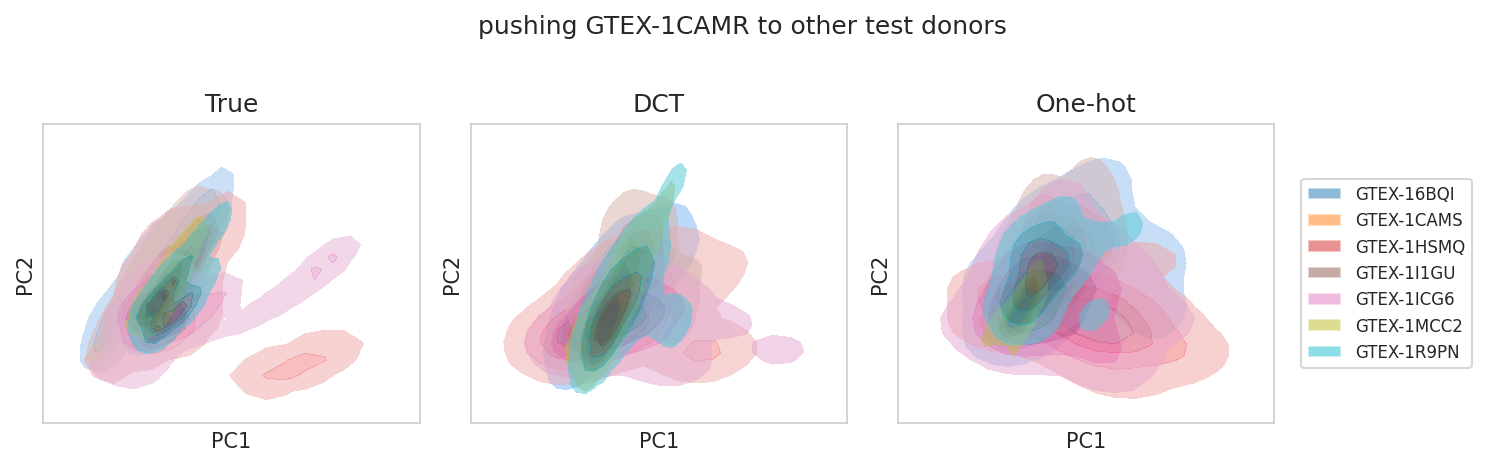

Source donor: GTEX-1CAMS
Target donors: ['GTEX-16BQI', 'GTEX-1CAMR', 'GTEX-1HSMQ', 'GTEX-1I1GU', 'GTEX-1ICG6', 'GTEX-1MCC2', 'GTEX-1R9PN']
Source has 2324 cells


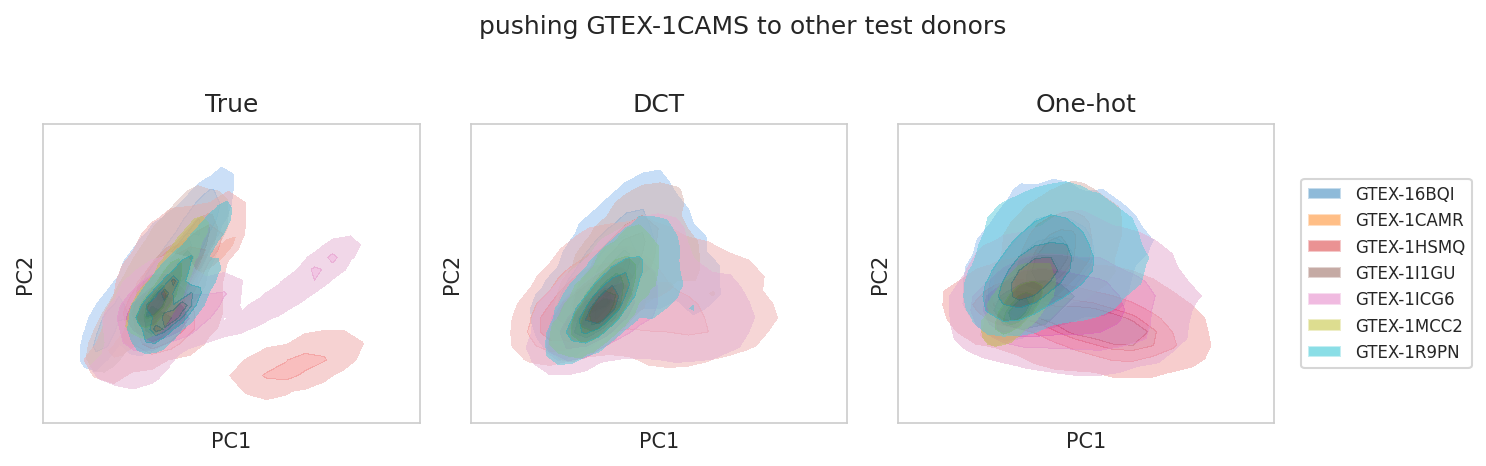

Source donor: GTEX-1HSMQ
Target donors: ['GTEX-16BQI', 'GTEX-1CAMR', 'GTEX-1CAMS', 'GTEX-1I1GU', 'GTEX-1ICG6', 'GTEX-1MCC2', 'GTEX-1R9PN']
Source has 54561 cells


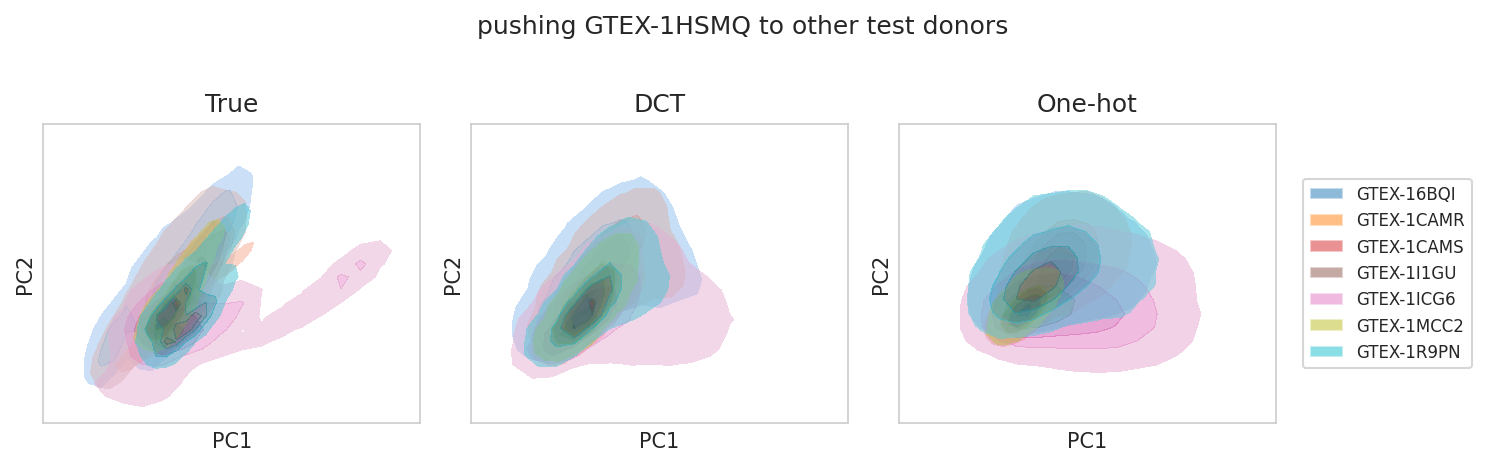

Source donor: GTEX-1I1GU
Target donors: ['GTEX-16BQI', 'GTEX-1CAMR', 'GTEX-1CAMS', 'GTEX-1HSMQ', 'GTEX-1ICG6', 'GTEX-1MCC2', 'GTEX-1R9PN']
Source has 12927 cells


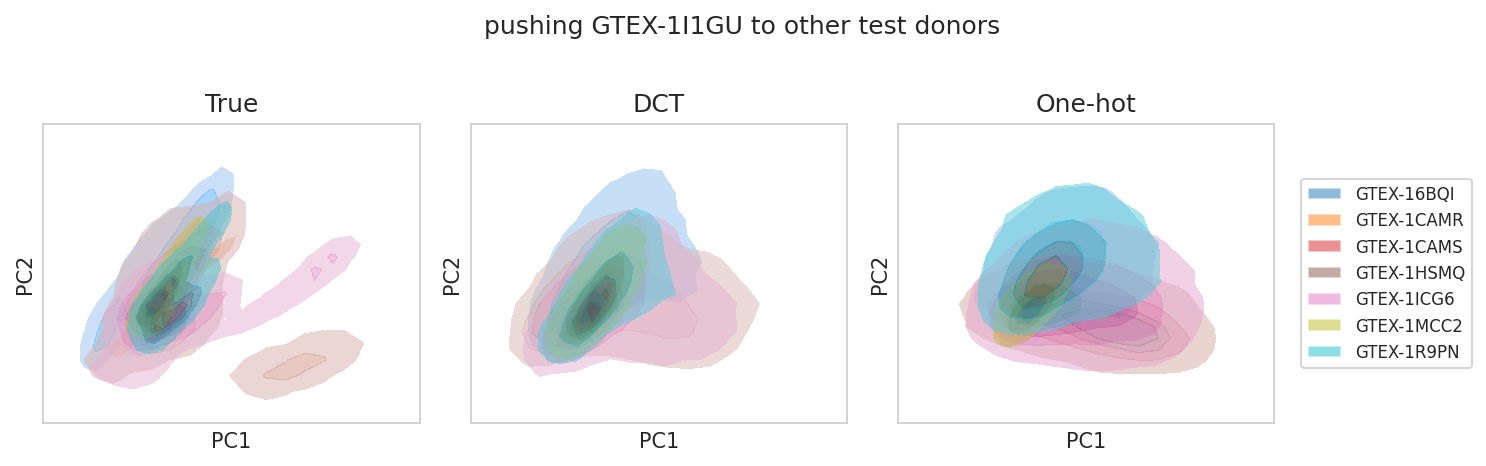

Source donor: GTEX-1ICG6
Target donors: ['GTEX-16BQI', 'GTEX-1CAMR', 'GTEX-1CAMS', 'GTEX-1HSMQ', 'GTEX-1I1GU', 'GTEX-1MCC2', 'GTEX-1R9PN']
Source has 20957 cells


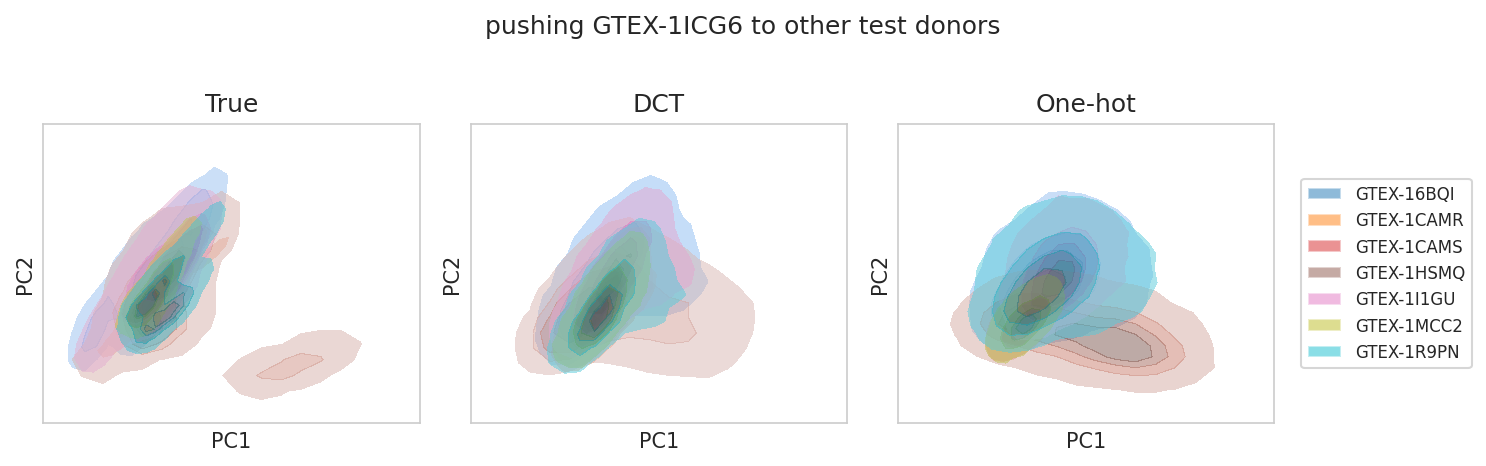

Source donor: GTEX-1MCC2
Target donors: ['GTEX-16BQI', 'GTEX-1CAMR', 'GTEX-1CAMS', 'GTEX-1HSMQ', 'GTEX-1I1GU', 'GTEX-1ICG6', 'GTEX-1R9PN']
Source has 1456 cells


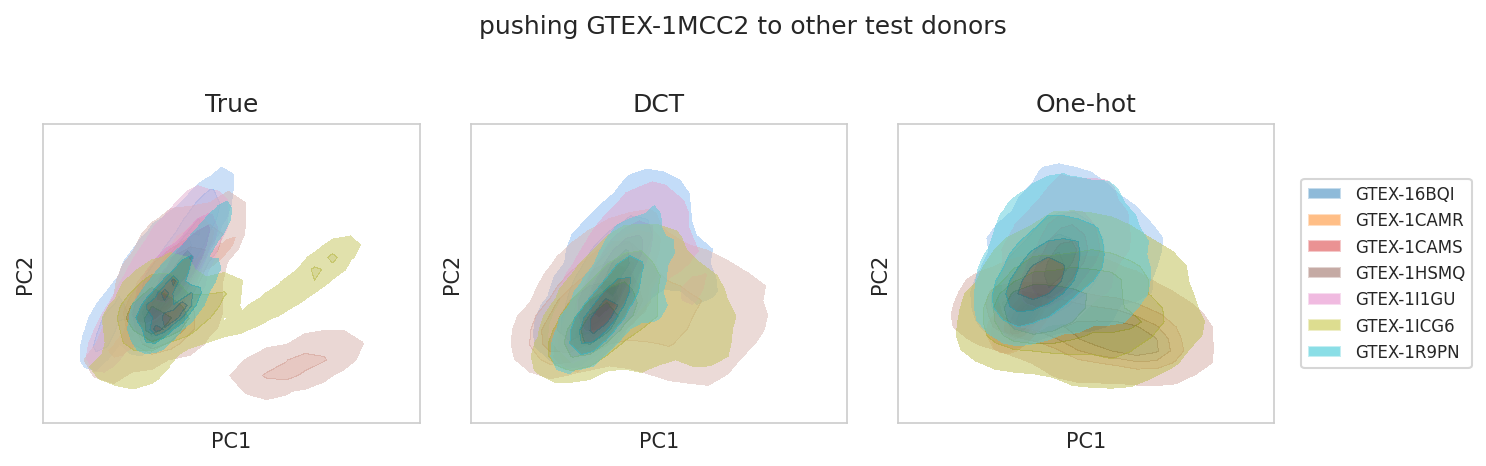

Source donor: GTEX-1R9PN
Target donors: ['GTEX-16BQI', 'GTEX-1CAMR', 'GTEX-1CAMS', 'GTEX-1HSMQ', 'GTEX-1I1GU', 'GTEX-1ICG6', 'GTEX-1MCC2']
Source has 5990 cells


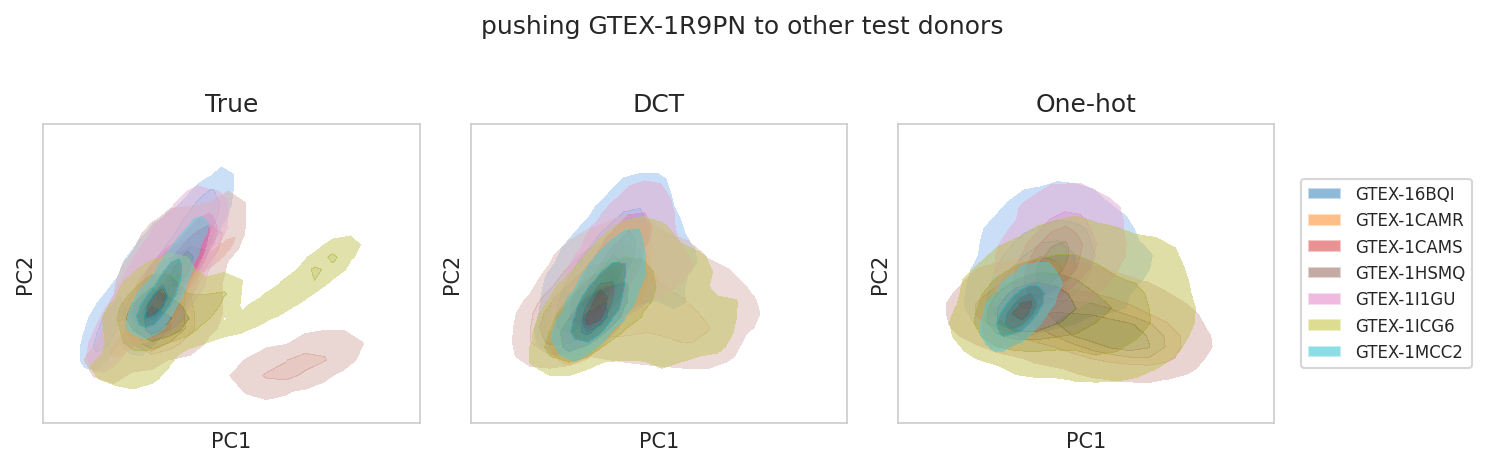

In [75]:
for source_donor in test_donors:

    print(f"Source donor: {source_donor}")
    print(f"Target donors: {[d for d in test_donors if d != source_donor]}")

    # Get all cells from source donor
    source_mask = adata_scvi.obs['donor_id'] == source_donor
    source_cells = adata_scvi[source_mask]
    source_pca = source_cells.obsm['X_pca'][:, :10]
    source_indices = np.where(source_mask)[0]

    print(f"Source has {len(source_pca)} cells")

    # Prepare data structures for predictions
    all_target_donors = [d for d in test_donors if d != source_donor]
    predictions = {
        'true': [],
        'dct': [],
        'onehot': [],
        # 'scvi': []
    }
    donor_labels = {
        'true': [],
        'dct': [],
        'onehot': [],
        # 'scvi': []
    }

    # For each target donor, get true data and predictions
    for target_donor in all_target_donors:
        # Get true target cells
        target_mask = adata_scvi.obs['donor_id'] == target_donor
        target_cells = adata_scvi[target_mask]
        target_pca = target_cells.obsm['X_pca'][:, :10]
        
        predictions['true'].append(target_pca)
        donor_labels['true'].extend([target_donor] * len(target_pca))
        
        # Prepare source data as tensors
        source_tensor = torch.tensor(source_pca, dtype=torch.float32).to(device)
        target_tensor = torch.tensor(target_pca, dtype=torch.float32).to(device)
        
        # DCT predictions
        with torch.no_grad():
            source_latent = dct_encoder(source_tensor.unsqueeze(0))
            target_latent = dct_encoder(target_tensor.unsqueeze(0))
            dct_pred = dct_generator.sample(source_tensor, source_latent, target_latent)
        
        # Ensure 2D shape (n_cells, n_features)
        dct_pred = dct_pred.squeeze()
        if len(dct_pred.shape) == 1:
            dct_pred = dct_pred.unsqueeze(0)
        predictions['dct'].append(dct_pred.cpu().numpy())
        donor_labels['dct'].extend([target_donor] * len(dct_pred))
        
        # OneHot predictions
        nearest_source_donor = test_to_train_donor[source_donor]
        nearest_target_donor = test_to_train_donor[target_donor]
        nn_source_idx = torch.tensor(train_set.donors.index(nearest_source_donor)).cuda()
        nn_target_idx = torch.tensor(train_set.donors.index(nearest_target_donor)).cuda()
        
        with torch.no_grad():
            onehot_source_latent = onehot_encoder(nn_source_idx).repeat(len(source_tensor), 1)
            onehot_target_latent = onehot_encoder(nn_target_idx).repeat(len(source_tensor), 1)
            onehot_pred = onehot_generator.sample(source_tensor, onehot_source_latent, onehot_target_latent)
        
        # Ensure 2D shape (n_cells, n_features)
        onehot_pred = onehot_pred.squeeze()
        if len(onehot_pred.shape) == 1:
            onehot_pred = onehot_pred.unsqueeze(0)
        predictions['onehot'].append(onehot_pred.cpu().numpy())
        donor_labels['onehot'].extend([target_donor] * len(onehot_pred))
        
        # # scVI predictions
        # adata_source = adata_scvi[source_indices].copy()
        # transformed = model.get_normalized_expression(
        #     adata_source, batch_size=512, transform_batch=target_donor
        # )
        # nns = nbrs.kneighbors(transformed, return_distance=False)
        # scvi_pred = adata_scvi.obsm['X_pca'][nns.flatten(), :10]
        # predictions['scvi'].append(scvi_pred)
        # donor_labels['scvi'].extend([target_donor] * len(scvi_pred))

    # Concatenate all predictions
    for method in predictions:
        predictions[method] = np.vstack(predictions[method])

    # Create the 3-panel plot
    fig, axes = plt.subplots(1, 3, figsize=(10, 3), dpi=150)

    methods = ['true', 'dct', 'onehot']
    titles = ['True', 'DCT', 'One-hot']

    # Use consistent colors for donors across all subplots
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_target_donors)))
    donor_colors = dict(zip(all_target_donors, colors))
    
    for ax, method, title in zip(axes, methods, titles):
        data = predictions[method]
        labels = donor_labels[method]
        
        # Plot with different colors for each target donor
        for target_donor in all_target_donors:
            mask = np.array(labels) == target_donor
            sns.kdeplot(
                x=data[mask, 0],
                y=data[mask, 1],
                ax=ax,
                fill=True,
                alpha=0.5,
                color=donor_colors[target_donor],
                thresh=0.05,
                levels=5,
                gridsize=20
            )
        
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title)

    # Create custom legend patches
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=donor_colors[donor], alpha=0.5, label=donor) 
                      for donor in all_target_donors]
    
    # Add legend to the right of the third subplot
    axes[-1].legend(handles=legend_elements, fontsize=8, loc='center left', bbox_to_anchor=(1.05, 0.5))

    plt.suptitle(f'pushing {source_donor} to other test donors', y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
for source_donor in test_donors:

    print(f"Source donor: {source_donor}")
    print(f"Target donors: {[d for d in test_donors if d != source_donor]}")

    # Get all cells from source donor
    source_mask = adata_scvi.obs['donor_id'] == source_donor
    source_cells = adata_scvi[source_mask]
    source_pca = source_cells.obsm['X_pca'][:, :10]
    source_indices = np.where(source_mask)[0]

    print(f"Source has {len(source_pca)} cells")

    # Prepare data structures for predictions
    all_target_donors = [d for d in test_donors if d != source_donor]
    predictions = {
        'true': [],
        'dct': [],
        'onehot': [],
        # 'scvi': []
    }
    donor_labels = {
        'true': [],
        'dct': [],
        'onehot': [],
        # 'scvi': []
    }

    # For each target donor, get true data and predictions
    for target_donor in all_target_donors:
        # Get true target cells
        target_mask = adata_scvi.obs['donor_id'] == target_donor
        target_cells = adata_scvi[target_mask]
        target_pca = target_cells.obsm['X_pca'][:, :10]
        
        predictions['true'].append(target_pca)
        donor_labels['true'].extend([target_donor] * len(target_pca))
        
        # Prepare source data as tensors
        source_tensor = torch.tensor(source_pca, dtype=torch.float32).to(device)
        target_tensor = torch.tensor(target_pca, dtype=torch.float32).to(device)
        
        # DCT predictions
        with torch.no_grad():
            source_latent = dct_encoder(source_tensor.unsqueeze(0))
            target_latent = dct_encoder(target_tensor.unsqueeze(0))
            dct_pred = dct_generator.sample(source_tensor, source_latent, target_latent, return_trajectory=True)